In [2]:
from fastai.vision.all import *

In [3]:
import torch

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
path = Path("data")

In [5]:
train_path = path / "train"
get_image_files(train_path)[:5]

[Path('data/train/Early_blight/IMG20220323100125.jpg'), Path('data/train/Early_blight/IMG20220323100125_1.jpg'), Path('data/train/Early_blight/IMG20220323100125_2.jpg'), Path('data/train/Early_blight/IMG20220323100125_3.jpg'), Path('data/train/Early_blight/IMG20220323100125_4.jpg')]

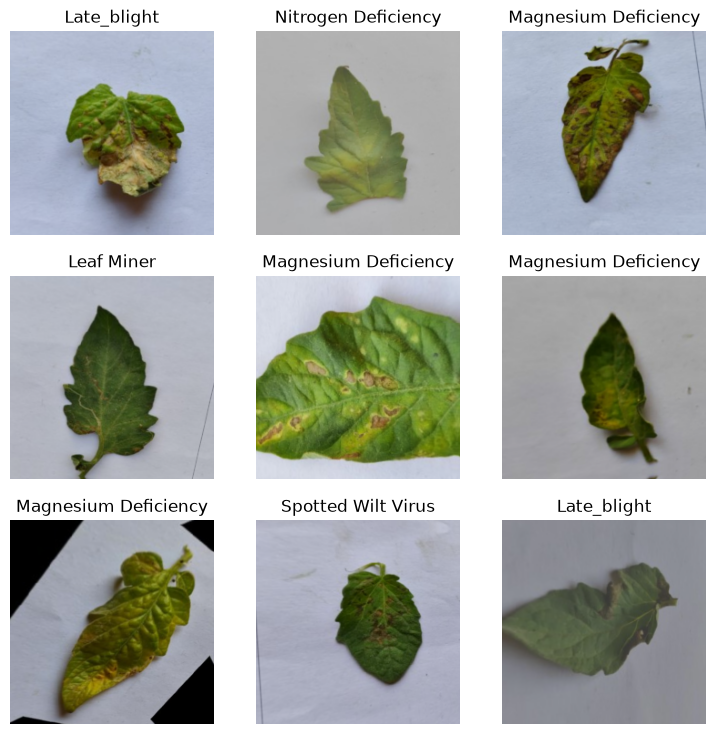

In [6]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='val'),
    get_y=parent_label,
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224)
).dataloaders(path, bs=16)

dls.show_batch()

In [7]:
dls.vocab

['Early_blight', 'Healthy', 'Late_blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Potassium Deficiency', 'Spotted Wilt Virus']

In [8]:
len(dls.train), len(dls.valid)

(197, 57)

In [9]:
dls.train.n, dls.valid.n

(3162, 902)

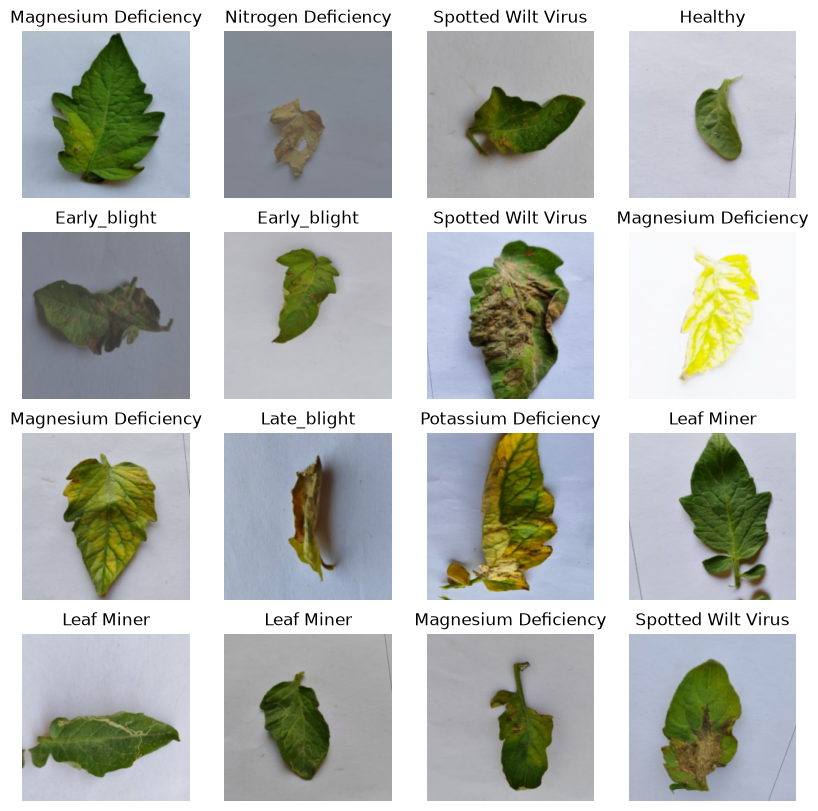

In [10]:
dls.show_batch(max_n=16, figsize=(10, 10))

In [11]:
learn = vision_learner(dls, resnet50, metrics=accuracy)

learn.fine_tune(
    10,
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_model'
    )
)

epoch,train_loss,valid_loss,accuracy,time
0,1.683418,1.044888,0.659645,00:32


Better model found at epoch 0 with valid_loss value: 1.0448877811431885.


epoch,train_loss,valid_loss,accuracy,time
0,1.015084,0.684811,0.770510,00:33
1,0.792247,0.569650,0.801552,00:33
2,0.743171,0.423212,0.863636,00:33
3,0.511596,0.362312,0.884701,00:33
4,0.419894,0.332306,0.890244,00:33
5,0.309139,0.440949,0.885809,00:33
6,0.245159,0.681846,0.859202,00:34
7,0.207857,0.273655,0.920177,00:34
8,0.156983,0.275543,0.920177,00:34
9,0.154399,0.286708,0.917960,00:35


Better model found at epoch 0 with valid_loss value: 0.6848108768463135.
Better model found at epoch 1 with valid_loss value: 0.569650411605835.
Better model found at epoch 2 with valid_loss value: 0.4232119619846344.
Better model found at epoch 3 with valid_loss value: 0.36231160163879395.
Better model found at epoch 4 with valid_loss value: 0.33230555057525635.
Better model found at epoch 7 with valid_loss value: 0.2736552655696869.


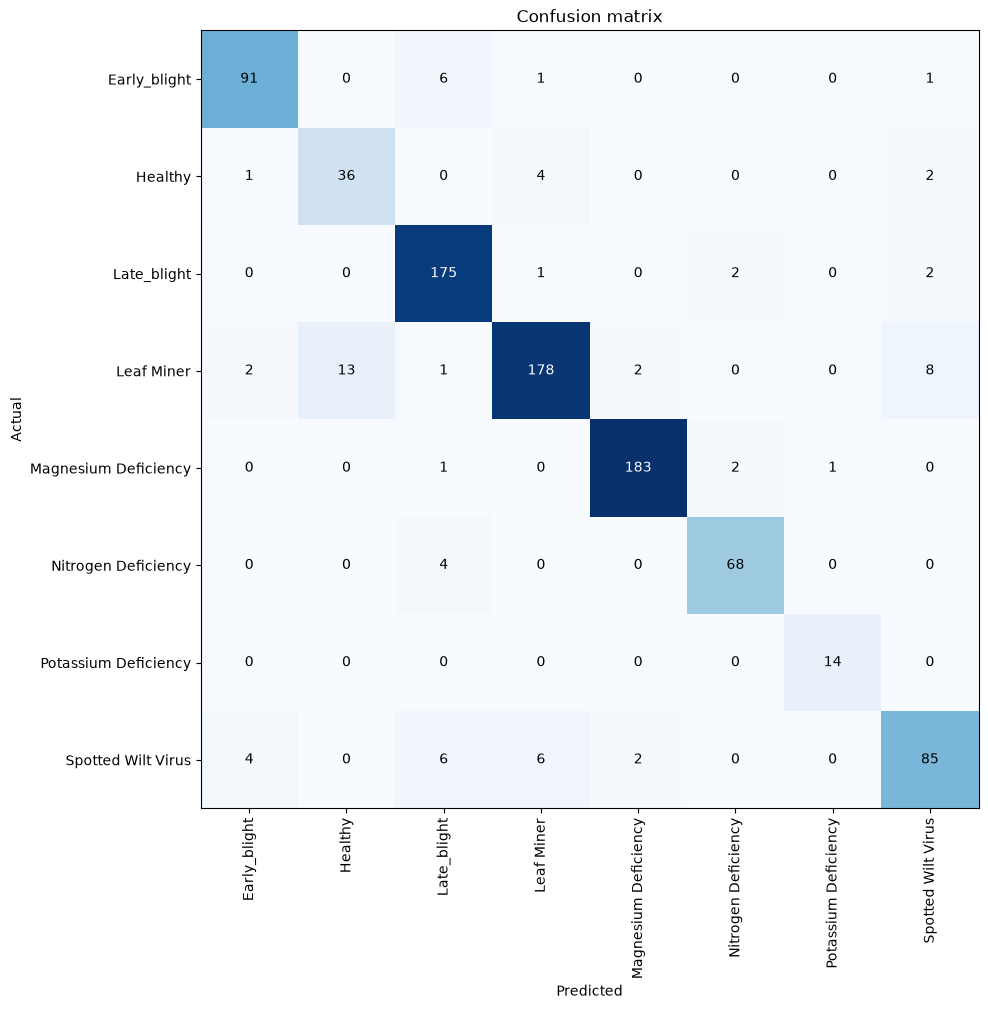

In [12]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(10, 10))

c:\Users\ssult\dl-env\.venv\Lib\site-packages\fastai\learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


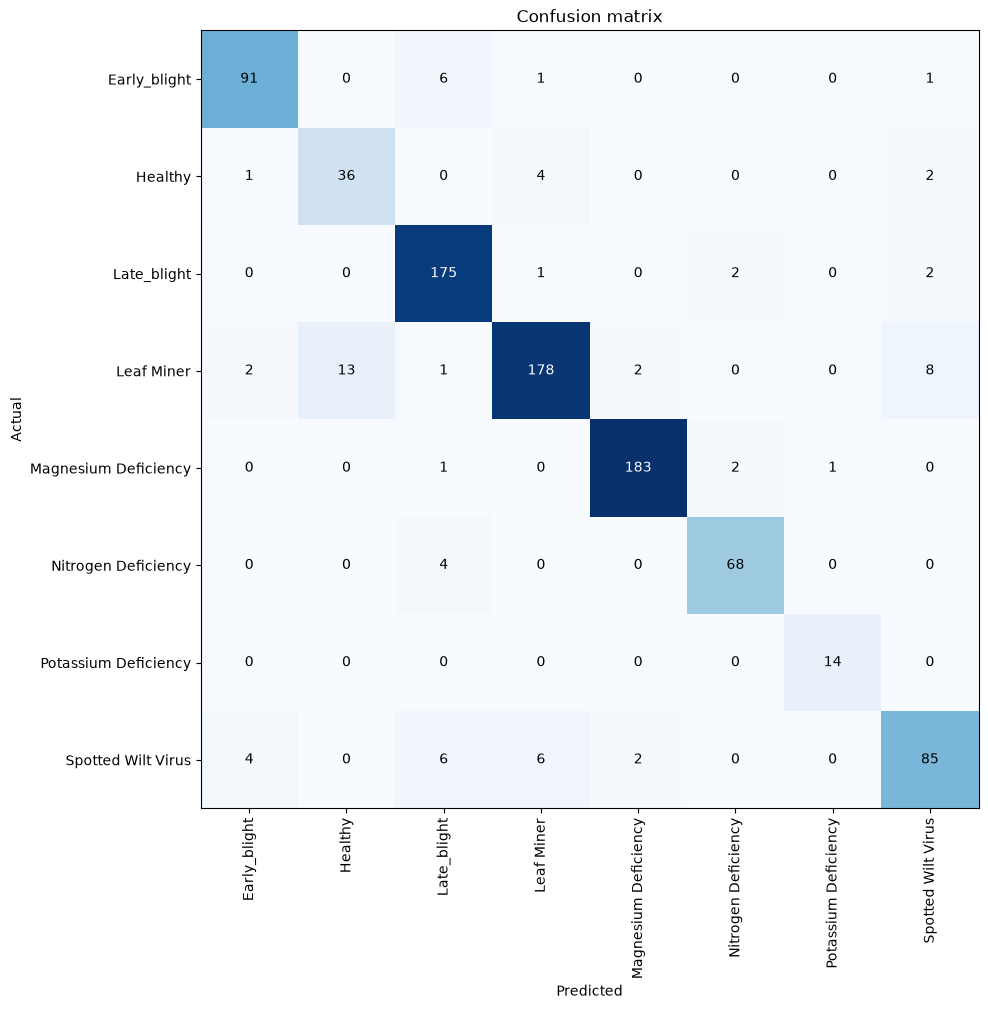

In [13]:

learn.load('best_model')
interp = ClassificationInterpretation.from_learner(learn)

interp.plot_confusion_matrix(figsize=(10, 10))

In [15]:
test_files = get_image_files(path / "test")

test_dl = dls.test_dl(test_files, with_labels=True)

learn.load('best_model')
learn.validate(dl=test_dl)

[0.1985245794057846, 0.9349240660667419]

In [16]:
learn.load('best_model')

In [17]:
learn.export('tomato_disease_model.pkl')

here the stuff is fully done al;l i have to later do is just convert the pkl into the cpu accesable format as its currently trained on my rtx cuda .....

before deploying also try using the efficient b0 once.
the aiml is separate so jussst done mix it with backend..
makesure u also add more pictures to this potassium dataset as it can increase the accuracy....
also write the fast ai reqt later..